<a href="https://colab.research.google.com/github/amaljudelitto/card-economy-sim/blob/main/analysis/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simulating 10000 matches. Please wait...
Simulation complete! Data saved to CSV.

--- BALANCE REPORT ---
Player 1 (Goes First) Win Rate: 64.63%
Player 2 (Goes Second) Win Rate: 35.37%



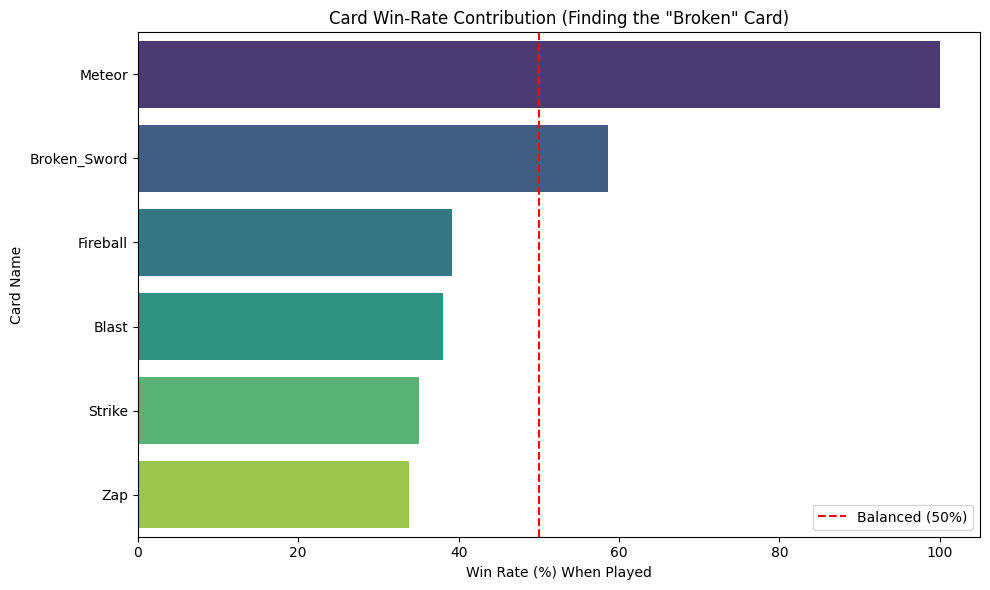

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ==========================================
# PART 1: THE GAME ENGINE & AI AGENTS
# ==========================================
class Card:
    def __init__(self, card_id, name, cost, damage):
        self.id = card_id
        self.name = name
        self.cost = cost
        self.damage = damage

class Player:
    def __init__(self, player_id, deck):
        self.id = player_id
        self.hp = 20
        self.mana = 0
        self.max_mana = 0
        self.deck = deck.copy()
        random.shuffle(self.deck)
        self.hand = []
        self.cards_played_this_match = []
        for _ in range(4): self.draw_card()

    def draw_card(self):
        if self.deck: self.hand.append(self.deck.pop(0))

class GameState:
    def __init__(self, p1_deck, p2_deck):
        self.p1 = Player(1, p1_deck)
        self.p2 = Player(2, p2_deck)
        self.turn_count = 0
        self.current_player = self.p1
        self.opponent = self.p2
        self.winner = None

    def play_turn(self, agent_logic):
        if self.current_player.id == 1: self.turn_count += 1
        if self.current_player.max_mana < 10: self.current_player.max_mana += 1

        self.current_player.mana = self.current_player.max_mana
        self.current_player.draw_card()

        cards_to_play = agent_logic(self.current_player)
        for card in cards_to_play:
            self.current_player.mana -= card.cost
            self.opponent.hp -= card.damage
            self.current_player.hand.remove(card)
            self.current_player.cards_played_this_match.append(card.name)
            if self.opponent.hp <= 0:
                self.winner = self.current_player.id
                return True

        self.current_player, self.opponent = self.opponent, self.current_player
        return False

def heuristic_agent(player):
    playable = sorted([c for c in player.hand if c.cost <= player.mana],
                      key=lambda x: x.damage, reverse=True)
    played = []
    current_mana = player.mana
    for card in playable:
        if card.cost <= current_mana:
            played.append(card)
            current_mana -= card.cost
    return played

def create_deck(include_op_card=False):
    deck = [
        Card(1, "Strike", 1, 2), Card(2, "Strike", 1, 2),
        Card(3, "Blast", 2, 4), Card(4, "Blast", 2, 4),
        Card(5, "Fireball", 3, 6), Card(6, "Fireball", 3, 6),
        Card(7, "Meteor", 5, 10), Card(8, "Meteor", 5, 10),
        Card(9, "Zap", 0, 1), Card(10, "Zap", 0, 1)
    ] * 2
    if include_op_card:
        deck[0] = Card(11, "Broken_Sword", 1, 7) # Intentionally unbalanced card
    return deck

# ==========================================
# PART 2: THE MONTE CARLO SIMULATION
# ==========================================
def run_monte_carlo(iterations=10000):
    print(f"Simulating {iterations} matches. Please wait...")
    match_logs = []

    for i in range(iterations):
        game = GameState(create_deck(), create_deck(include_op_card=True))
        while not game.winner and game.turn_count < 50:
            if game.play_turn(heuristic_agent): break

        match_logs.append({
            'match_id': i,
            'winner': game.winner,
            'total_turns': game.turn_count,
            'p1_cards_played': ",".join(game.p1.cards_played_this_match),
            'p2_cards_played': ",".join(game.p2.cards_played_this_match)
        })

    df = pd.DataFrame(match_logs)
    df.to_csv("simulation_results.csv", index=False) # Creates the file in Colab!
    print("Simulation complete! Data saved to CSV.\n")

# Run 10,000 matches (lowered slightly so it runs fast in the browser)
run_monte_carlo(10000)

# ==========================================
# PART 3: DATA ANALYSIS & VISUALIZATION
# ==========================================
df = pd.read_csv("simulation_results.csv")

# 1. First-Turn Advantage
p1_win_rate = (df['winner'] == 1).mean() * 100
p2_win_rate = (df['winner'] == 2).mean() * 100
print("--- BALANCE REPORT ---")
print(f"Player 1 (Goes First) Win Rate: {p1_win_rate:.2f}%")
print(f"Player 2 (Goes Second) Win Rate: {p2_win_rate:.2f}%\n")

# 2. Card Win-Rate Contribution
def calculate_card_winrate(df, player_id):
    card_wins, card_plays = {}, {}
    column = f'p{player_id}_cards_played'
    player_games = df[df[column].notna()]

    for _, row in player_games.iterrows():
        cards = str(row[column]).split(',')
        won = 1 if row['winner'] == player_id else 0
        for card in set(cards):
            if card == "": continue
            card_plays[card] = card_plays.get(card, 0) + 1
            card_wins[card] = card_wins.get(card, 0) + won

    winrates = {card: (wins / card_plays[card]) * 100 for card, wins in card_wins.items()}
    return pd.DataFrame(list(winrates.items()), columns=['Card', 'WinRate']).sort_values('WinRate', ascending=False)

p2_stats = calculate_card_winrate(df, 2)

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='WinRate', y='Card', data=p2_stats, palette='viridis', hue='Card')
plt.title('Card Win-Rate Contribution (Finding the "Broken" Card)')
plt.xlabel('Win Rate (%) When Played')
plt.ylabel('Card Name')
plt.axvline(x=50, color='r', linestyle='--', label='Balanced (50%)')
plt.legend()
plt.tight_layout()
plt.show()